# Parameters

In [39]:
DATA_PATH = "/kaggle/input/gan-getting-started"
SNAP_PATH = "/home/vazzu/Desktop/GAN"
LEARNING_RATE_G = 2e-4  # Standard CycleGAN value
LEARNING_RATE_D = 5e-5  # Slowed down significantly
LAMBDA_CYCLE = 10.0
LAMBDA_ID = 5.0
DROPOUT=0.3
N_RES_BLOCKS=9

# Wandb

In [2]:
!pip install -q wandb

# Imports

In [3]:
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.init as init
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms
from torchsummary import summary

In [4]:
import PIL
from PIL import Image
import matplotlib.pyplot as plt

In [5]:
import itertools
import os
import random
import shutil
import time
from tqdm.notebook import tqdm
import uuid

In [6]:
import wandb
# API KEY HERE
wandb.login(key="")

/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

True

In [7]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

# Photo/Monet Dataset

In [8]:
class MonetDataset(Dataset):
  def __init__(self, monet_dir, photo_dir, transform):
    self.monet_dir = monet_dir
    self.photo_dir = photo_dir
    self.monet = [os.path.join(monet_dir, f) for f in os.listdir(monet_dir)]
    self.photo = [os.path.join(photo_dir, f) for f in os.listdir(photo_dir)]
    self.transform = transform

  def __len__(self):
    return min(len(self.monet), len(self.photo))

  def __getitem__(self, idx):
    monet = Image.open(self.monet[idx]).convert("RGB")
    photo = Image.open(random.choice(self.photo)).convert("RGB")

    monet = self.transform(monet)
    photo = self.transform(photo)

    return photo, monet

In [9]:
t = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [10]:
dataset = MonetDataset(
  f"{DATA_PATH}/monet_jpg/",
  f"{DATA_PATH}/photo_jpg/",
  transform = t
)

In [11]:
loader = DataLoader(dataset, batch_size=1, pin_memory=True)

In [12]:
def tensor_to_image(x):
    img = x[0].permute(1, 2, 0).cpu()  # C,H,W -> H,W,C
    img = (img + 1) / 2  # [-1,1] -> [0,1]
    return img

def show2(photo, monet):
  photo = tensor_to_image(photo)
  monet = tensor_to_image(monet)

  fig, axes = plt.subplots(1, 2, figsize=(10,5))
  axes[0].imshow(photo)
  axes[0].set_title("Photo")
  axes[0].axis('off')

  axes[1].imshow(monet)
  axes[1].set_title("Monet")
  axes[1].axis('off')

  plt.show()

def show3(photo, fake_monet, reconst_photo):
  photo = tensor_to_image(photo)
  fake_monet = tensor_to_image(fake_monet)
  reconst_photo = tensor_to_image(reconst_photo)

  fig, axes = plt.subplots(1, 3, figsize=(10,5))
  axes[0].imshow(photo)
  axes[0].set_title("Photo")
  axes[0].axis('off')

  axes[1].imshow(fake_monet)
  axes[1].set_title("Fake Monet")
  axes[1].axis('off')

  axes[2].imshow(reconst_photo)
  axes[2].set_title("Photo reconstruction")
  axes[2].axis('off')

  plt.show()

In [13]:
def tensor_to_wandb(x):
    img = x[0].cpu()
    img = (img + 1) / 2  # [-1,1] -> [0,1]
    return img * 255

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


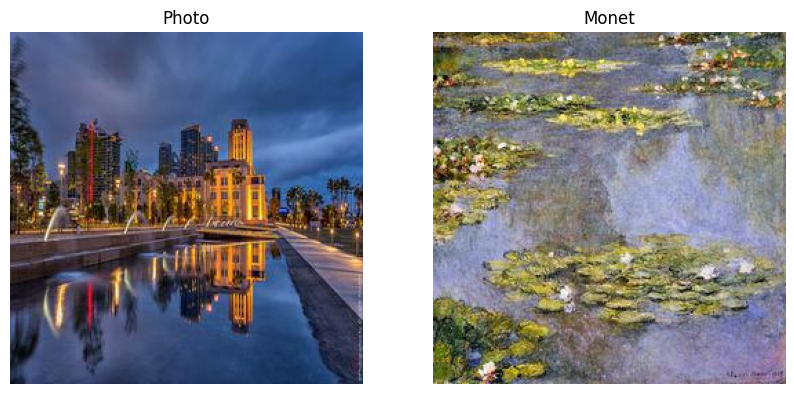

In [14]:
photo, monet = next(iter(loader))
show2(photo, monet)

# GAN Code

## Residual Neural Network Block

In [73]:
class ResNetBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(
                channels,
                channels,
                padding_mode="reflect",
                kernel_size=3,
                padding=1,
            ),
            nn.InstanceNorm2d(channels),
            nn.ReLU(),

            nn.Dropout(p=DROPOUT),
            
            nn.Conv2d(
                channels,
                channels,
                padding_mode="reflect",
                kernel_size=3,
                padding=1,
            ),
            nn.InstanceNorm2d(channels),
        )

    def forward(self, X):
        # Residual connection
        return X + self.seq(X)


## Generator (ResNet)

In [74]:
class Generator(nn.Module):
    def __init__(self, n_res_blocks=9):
        super().__init__()

        encoder = [
            nn.Conv2d(
                3,
                64,
                kernel_size=7,
                padding=3,
                stride=1,
                padding_mode="reflect",
            ),
            nn.InstanceNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.ReLU(),
        ]

        # ResNet blocks
        res_blocks = [ResNetBlock(256) for _ in range(n_res_blocks)]

        decoder = [
            nn.ConvTranspose2d(
                256, 128, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.InstanceNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(
                128, 64, kernel_size=3, stride=2, padding=1, output_padding=1
            ),
            nn.InstanceNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 3, kernel_size=7, padding=3, padding_mode="reflect"),
            nn.Tanh(),
        ]

        self.seq = nn.Sequential(
            *encoder,
            *res_blocks,
            *decoder
        )

    def forward(self, x):
        return self.seq(x)


## Discriminator(PatchGAN)

In [75]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.seq = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(p=DROPOUT),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(256),
            nn.LeakyReLU(0.2),
            nn.Dropout(p=DROPOUT),

            nn.Conv2d(256, 512, kernel_size=4, stride=1, padding=1),
            nn.InstanceNorm2d(512),
            nn.LeakyReLU(0.2),
            nn.Dropout(p=DROPOUT),

            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=1),
        )

    def forward(self, x):
        return self.seq(x)


## CycleGAN

In [48]:
def weights_init(m):
    classname = m.__class__.__name__
    # Apply to Convolutional and Linear layers
    if classname.find("Conv") != -1 or classname.find("Linear") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0.0)

In [76]:
class CycleGAN(nn.Module):
    def __init__(
        self,
        G_photo_monet,
        G_monet_photo,
        D_photo,
        D_monet,
        lambda_cycle=10.0,
        lambda_id=5.0
    ):
        super().__init__()
        self.G_photo_monet = G_photo_monet
        self.G_monet_photo = G_monet_photo
        self.D_photo = D_photo
        self.D_monet = D_monet

        self.G_photo_monet.apply(weights_init)
        self.G_monet_photo.apply(weights_init)
        self.D_photo.apply(weights_init)
        self.D_monet.apply(weights_init)

        self.lambda_cycle = lambda_cycle
        self.lambda_id = lambda_id

        self.mae = nn.L1Loss()

        self.opt_G = optim.Adam(
            list(G_photo_monet.parameters()) + list(G_monet_photo.parameters()),
            lr=LEARNING_RATE_G,
            betas=(0.5, 0.999),
        )
        self.opt_D = optim.Adam(
            list(D_photo.parameters()) + list(D_monet.parameters()),
            lr=LEARNING_RATE_D,
            betas=(0.5, 0.999),
        )

    def train_step(self, real_photo, real_monet):
        # Switch to train mode
        self.G_photo_monet.train()
        self.G_monet_photo.train()
        self.D_photo.train()
        self.D_monet.train()

        # ======== Generators ========
        self.opt_G.zero_grad()

        fake_monet = self.G_photo_monet(real_photo)
        fake_photo = self.G_monet_photo(real_monet)

        # Hinge Adversarial loss
        loss_G_photo_monet = -self.D_monet(fake_monet).mean()
        loss_G_monet_photo = -self.D_photo(fake_photo).mean()

        # Cycle
        reconst_photo = self.G_monet_photo(fake_monet)
        reconst_monet = self.G_photo_monet(fake_photo)
        loss_cycle_photo = self.mae(reconst_photo, real_photo)
        loss_cycle_monet = self.mae(reconst_monet, real_monet)
        loss_cycle = loss_cycle_photo + loss_cycle_monet

        # Identity
        # id_photo = self.G_monet_photo(real_photo)
        # id_monet = self.G_photo_monet(real_monet)

        # loss_id_photo = self.mae(id_photo, real_photo)
        # loss_id_monet = self.mae(id_monet, real_monet)
        # loss_id = loss_id_photo + loss_id_monet

        # Total loss
        loss_G = (
            loss_G_photo_monet + loss_G_monet_photo +
            self.lambda_cycle * loss_cycle
        )
        # self.lambda_id * loss_id

        loss_G.backward()
        self.opt_G.step()
        # ===========================

        # ======== Discriminators ========
        self.opt_D.zero_grad()

        out_D_real_photo = self.D_photo(real_photo)
        out_D_fake_photo = self.D_photo(fake_photo.detach())
        loss_D_photo = (
            torch.relu(1.0 - out_D_real_photo).mean() +
            torch.relu(1.0 + out_D_fake_photo).mean()
        )

        out_D_real_monet = self.D_monet(real_monet)
        out_D_fake_monet = self.D_monet(fake_monet.detach())
        loss_D_monet = (
            torch.relu(1.0 - out_D_real_monet).mean() +
            torch.relu(1.0 + out_D_fake_monet).mean()
        )

        loss_D = (loss_D_photo + loss_D_monet) * 0.5

        loss_D.backward()
        self.opt_D.step()
        # ================================

        return {
            "G/loss_photo": loss_G_photo_monet.item(),
            "G/loss_monet": loss_G_monet_photo.item(),
            "G/loss_cycle": loss_cycle.item(),
            # "G/loss_id": loss_id.item(),
            "G/loss": loss_G.item(),
            "D/loss_photo": loss_D_photo.item(),
            "D/loss_monet": loss_D_monet.item(),
            "D/loss": loss_D.item(),
        }


In [77]:
def train_one_epoch(gan, loader):
    losses = None
    for photo, monet in tqdm(loader, desc="Training", unit="batch"):
        photo = photo.to(device, non_blocking=True)
        monet = monet.to(device, non_blocking=True)

        cur_losses = gan.train_step(photo, monet)

        if losses == None:
            losses = cur_losses
        else:
            for k, v in cur_losses.items():
                losses[k] += v

    for k, v in losses.items():
        losses[k] /= len(loader)

    return losses

In [78]:
def sample(gan, loader):
  photo, monet = next(iter(loader))

  real_photo = photo.to(device)

  gan.G_photo_monet.eval()
  gan.G_monet_photo.eval()

  with torch.no_grad():
    fake_monet = gan.G_photo_monet(real_photo)
    reconst_photo = gan.G_monet_photo(fake_monet)

  show3(photo, fake_monet, reconst_photo)

  return photo, fake_monet, reconst_photo

In [79]:
def show_all(photo, fake_monets, labels):
    photo = tensor_to_image(photo)

    fig, axes = plt.subplots(1, len(labels)+1, figsize=(15, 10))
    axes[0].imshow(photo)
    axes[0].set_title("Photo")
    axes[0].axis("off")

    for i in range(1, len(labels)+1):
        fake_monet = tensor_to_image(fake_monets[i-1])
        axes[i].imshow(fake_monet)
        axes[i].set_title(labels[i-1])
        axes[i].axis("off")

    plt.savefig(f"{uuid.uuid4().hex}.png")
    plt.show()

def sample_all(gans, labels, loader):
    photo, monet = next(iter(loader))

    real_photo = photo.to(device)

    fake_monets = []
    
    for gan in gans:
        gan.G_photo_monet.eval()
        with torch.no_grad():
            fake_monet = gan.G_photo_monet(real_photo)
            fake_monets.append(fake_monet)

    show_all(photo, fake_monets, labels)

# Inference

In [80]:
def save_snapshot(gan, epoch):
    name = f"{SNAP_PATH}/snapshot_epoch_{epoch}.pt"
    torch.save({
        "G_photo_monet": gan.G_photo_monet.state_dict(),
        "G_monet_photo": gan.G_monet_photo.state_dict(),
        "D_photo": gan.D_photo.state_dict(),
        "D_monet": gan.D_monet.state_dict(),
    }, name)
    return name

In [81]:
def load_snapshot(gan, path):
    ckpt = torch.load(path, map_location="cpu")
    gan.G_photo_monet.load_state_dict(ckpt["G_photo_monet"])
    gan.G_monet_photo.load_state_dict(ckpt["G_monet_photo"])
    gan.D_photo.load_state_dict(ckpt["D_photo"])
    gan.D_monet.load_state_dict(ckpt["D_monet"])

### Download model

In [82]:
!mkdir /tmp/model -p

In [83]:
import wandb
run = wandb.init()
artifact = run.use_artifact('vvaza22-free-university-of-tbilisi/GenModels-Assignment1/model_snapshot_epoch_50:v3', type='model')
#artifact = run.use_artifact('vvaza22-free-university-of-tbilisi/GenModels-Assignment1/model_snapshot_epoch_50:v9', type='model')
artifact_dir = artifact.download(root="/tmp/model")
print(artifact_dir)

wandb: Downloading large artifact 'model_snapshot_epoch_50:v4', 107.94MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.5 (196.3MB/s)


/tmp/model


In [84]:
!ls -lah /tmp/model

total 108M
drwxr-xr-x 2 root root 4.0K Dec 23 11:14 .
drwxrwxrwt 1 root root 4.0K Dec 23 11:33 ..
-rw-r--r-- 1 root root 108M Dec 23 11:29 snapshot_epoch_50.pt


In [85]:
gan = CycleGAN(
    G_photo_monet=Generator(n_res_blocks=9).to(device),
    G_monet_photo=Generator(n_res_blocks=9).to(device),
    D_photo=Discriminator().to(device),
    D_monet=Discriminator().to(device),
    lambda_cycle=LAMBDA_CYCLE,
    lambda_id=LAMBDA_ID
)

In [86]:
load_snapshot(gan, "/tmp/model/snapshot_epoch_50.pt")

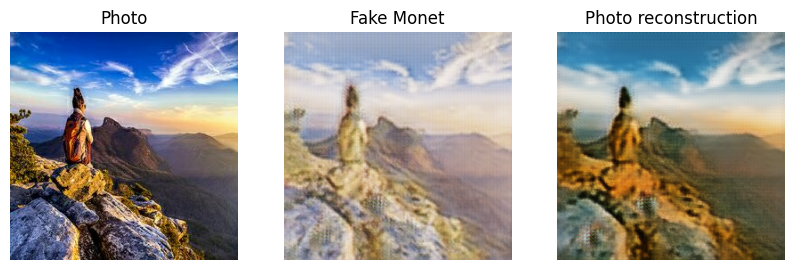

In [87]:
_, _, _ = sample(gan, loader)

In [88]:
class PhotoDataset(Dataset):
  def __init__(self, photo_dir, transform):
    self.photo_dir = photo_dir
    self.photo = [os.path.join(photo_dir, f) for f in os.listdir(photo_dir)]
    self.transform = transform

  def __len__(self):
    return len(self.photo)

  def __getitem__(self, idx):
    photo = Image.open(self.photo[idx]).convert("RGB")
    photo = self.transform(photo)
    return photo

In [89]:
import torchvision.transforms as transforms

tr = transforms.ToPILImage()
def conv(img):
    return tr((img[0]+1)/2)

In [90]:
photo_dataset = PhotoDataset(
  f"{DATA_PATH}/photo_jpg/",
  transform = t
)
photo_loader = DataLoader(photo_dataset, batch_size=1, pin_memory=True)

In [91]:
def run(photo, gan):
  real_photo = photo.to(device)

  gan.G_photo_monet.eval()

  with torch.no_grad():
    fake_monet = gan.G_photo_monet(real_photo)

  return fake_monet

In [92]:
!mkdir /tmp/out -p

In [ ]:
idx = 1
for photo in tqdm(photo_loader, desc="Inference", unit="batch"):
    fake_monet = run(photo, gan)
    conv(fake_monet).save(f"/tmp/out/{idx}.jpg")
    idx += 1

In [ ]:
import shutil
shutil.make_archive("/kaggle/working/images", 'zip', "/tmp/out")